In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/European_Bank.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (10000, 14)


In [5]:
print("\nColumns:")


Columns:


In [6]:
print(df.columns.tolist())

['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [7]:
print("\nData Types:")



Data Types:


In [8]:
print(df.dtypes)


Year                 int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [9]:
print("\nMissing Values:")


Missing Values:


In [10]:
print(df.isnull().sum())

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [11]:
print("Total Customers:", len(df))


Total Customers: 10000


In [12]:
print("Churned Customers:", df['Exited'].sum())


Churned Customers: 2037


In [13]:
print("Retained Customers:", len(df) - df['Exited'].sum())


Retained Customers: 7963


In [14]:
churn_rate = (df['Exited'].mean()) * 100

In [15]:
print(f"\nOverall Churn Rate: {churn_rate:.2f}%")



Overall Churn Rate: 20.37%


In [16]:
df_clean = df.drop(columns=['CustomerId', 'Surname'])


In [17]:
print("\nColumns after cleaning:")



Columns after cleaning:


In [18]:
print(df_clean.columns.tolist())

['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [19]:
# -------------------------------
# Churn Rate by Geography
# -------------------------------

geography_churn = (
    df.groupby('Geography')['Exited']
    .mean()
    .sort_values(ascending=False) * 100
)

print("Churn Rate by Geography (%)")
print(geography_churn)


# -------------------------------
# Churn Rate by Gender
# -------------------------------

gender_churn = (
    df.groupby('Gender')['Exited']
    .mean()
    .sort_values(ascending=False) * 100
)

print("\nChurn Rate by Gender (%)")
print(gender_churn)


# -------------------------------
# Number of customers by country
# -------------------------------

print("\nCustomer Distribution by Geography")
print(df['Geography'].value_counts())


# -------------------------------
# Number of churned customers by country
# -------------------------------

print("\nChurned Customers by Geography")
print(df[df['Exited'] == 1]['Geography'].value_counts())

Churn Rate by Geography (%)
Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64

Churn Rate by Gender (%)
Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

Customer Distribution by Geography
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Churned Customers by Geography
Geography
Germany    814
France     810
Spain      413
Name: count, dtype: int64


In [20]:
# =========================================
# Age Analysis
# =========================================

# Create Age Groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['<30', '30-45', '46-60', '60+']
)

# Churn Rate by Age Group
age_churn = (
    df.groupby('AgeGroup')['Exited']
    .mean()
    .sort_values(ascending=False) * 100
)

print("Churn Rate by Age Group (%)")
print(age_churn)

print("\n")

# Number of customers in each age group
print("Customer Distribution by Age Group")
print(df['AgeGroup'].value_counts())

print("\n")

# Number of churned customers in each age group
print("Churned Customers by Age Group")
print(df[df['Exited'] == 1]['AgeGroup'].value_counts())

Churn Rate by Age Group (%)
AgeGroup
46-60    51.123254
60+      24.784483
30-45    15.740584
<30       7.520325
Name: Exited, dtype: float64


Customer Distribution by Age Group
AgeGroup
30-45    5921
<30      1968
46-60    1647
60+       464
Name: count, dtype: int64


Churned Customers by Age Group
AgeGroup
30-45    932
46-60    842
<30      148
60+      115
Name: count, dtype: int64


In [21]:
# =========================================
# Credit Score Analysis
# =========================================

# Create Credit Score Categories
df['CreditCategory'] = pd.cut(
    df['CreditScore'],
    bins=[0, 580, 700, 850],
    labels=['Low', 'Medium', 'High']
)

# Churn rate by credit category
credit_churn = (
    df.groupby('CreditCategory')['Exited']
    .mean()
    .sort_values(ascending=False) * 100
)

print("Churn Rate by Credit Category (%)")
print(credit_churn)

print("\n")


# =========================================
# Balance Analysis
# =========================================

# Create Balance Categories
df['BalanceCategory'] = pd.cut(
    df['Balance'],
    bins=[-1, 0, 100000, 300000],
    labels=['Zero Balance', 'Low Balance', 'High Balance']
)

balance_churn = (
    df.groupby('BalanceCategory')['Exited']
    .mean()
    .sort_values(ascending=False) * 100
)

print("Churn Rate by Balance Category (%)")
print(balance_churn)

print("\n")


# =========================================
# High Value Customer Analysis
# =========================================

high_value_customers = df[df['Balance'] > 100000]

high_value_churn_rate = (
    high_value_customers['Exited'].mean() * 100
)

print("Number of High Value Customers:",
      len(high_value_customers))

print("High Value Customer Churn Rate:",
      round(high_value_churn_rate, 2), "%")

Churn Rate by Credit Category (%)
CreditCategory
Low       22.147931
High      19.865212
Medium    19.772879
Name: Exited, dtype: float64


Churn Rate by Balance Category (%)
BalanceCategory
High Balance    25.234424
Low Balance     20.580808
Zero Balance    13.823611
Name: Exited, dtype: float64


Number of High Value Customers: 4799
High Value Customer Churn Rate: 25.23 %


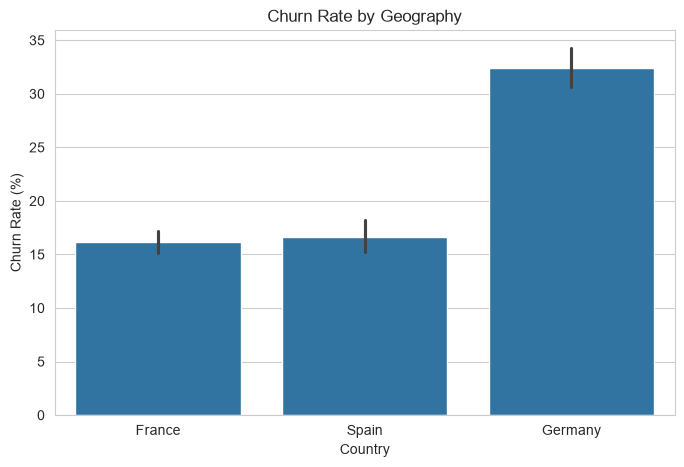

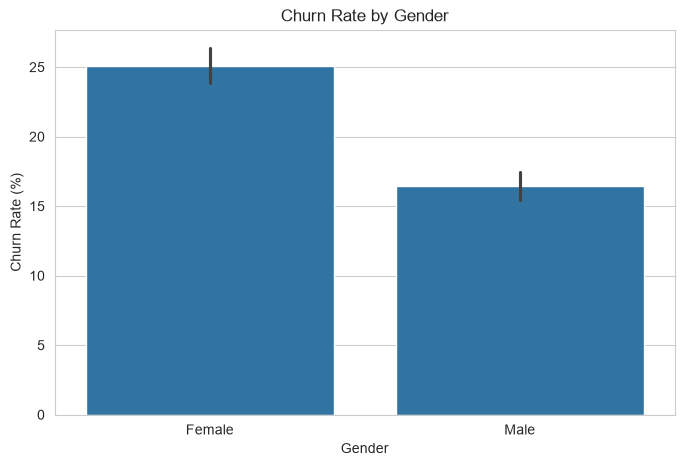

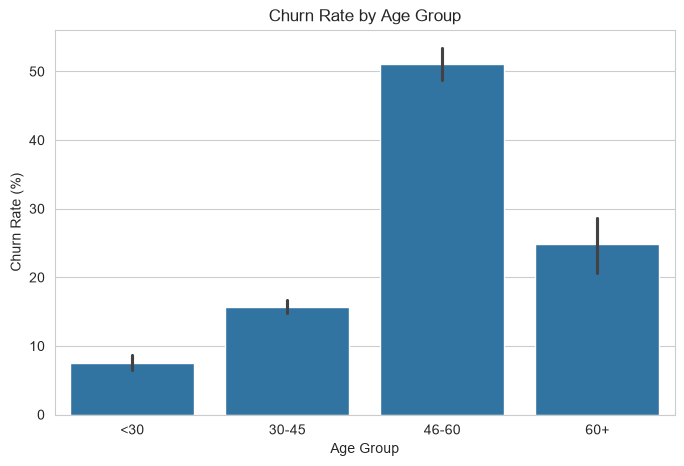

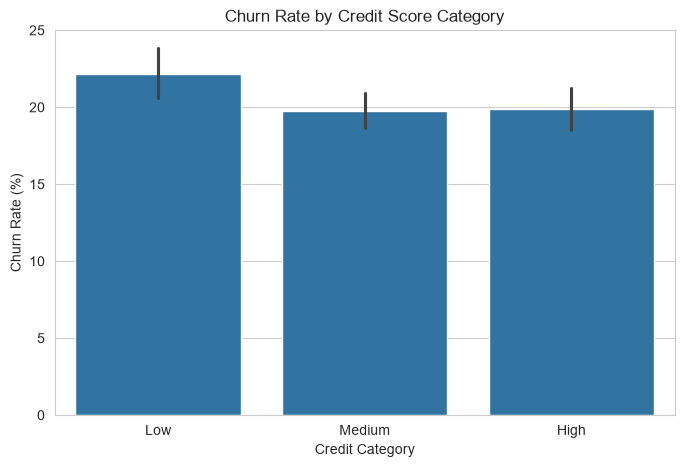

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better chart style
sns.set_style("whitegrid")

# -----------------------------
# Churn by Geography
# -----------------------------
plt.figure(figsize=(8,5))
sns.barplot(
    x='Geography',
    y='Exited',
    data=df,
    estimator=lambda x: x.mean()*100
)
plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Country")
plt.show()


# -----------------------------
# Churn by Gender
# -----------------------------
plt.figure(figsize=(8,5))
sns.barplot(
    x='Gender',
    y='Exited',
    data=df,
    estimator=lambda x: x.mean()*100
)
plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Gender")
plt.show()


# -----------------------------
# Churn by Age Group
# -----------------------------
plt.figure(figsize=(8,5))
sns.barplot(
    x='AgeGroup',
    y='Exited',
    data=df,
    estimator=lambda x: x.mean()*100
)
plt.title("Churn Rate by Age Group")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Age Group")
plt.show()


# -----------------------------
# Churn by Credit Category
# -----------------------------
plt.figure(figsize=(8,5))
sns.barplot(
    x='CreditCategory',
    y='Exited',
    data=df,
    estimator=lambda x: x.mean()*100
)
plt.title("Churn Rate by Credit Score Category")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Credit Category")
plt.show()

In [23]:
# =========================================
# Tenure Group Analysis
# =========================================

df['TenureGroup'] = pd.cut(
    df['Tenure'],
    bins=[-1, 2, 6, 10],
    labels=['New Customer', 'Mid-Term Customer', 'Long-Term Customer']
)

tenure_churn = (
    df.groupby('TenureGroup')['Exited']
    .mean() * 100
)

print("Churn Rate by Tenure Group (%)")
print(tenure_churn)

print("\n")


# =========================================
# Active vs Inactive Customer Analysis
# =========================================

activity_churn = (
    df.groupby('IsActiveMember')['Exited']
    .mean() * 100
)

print("Churn Rate by Activity Status (%)")
print(activity_churn)

print("\n")


# =========================================
# Credit Card Analysis
# =========================================

creditcard_churn = (
    df.groupby('HasCrCard')['Exited']
    .mean() * 100
)

print("Churn Rate by Credit Card Ownership (%)")
print(creditcard_churn)

print("\n")


# =========================================
# Products Analysis
# =========================================

product_churn = (
    df.groupby('NumOfProducts')['Exited']
    .mean() * 100
)

print("Churn Rate by Number of Products (%)")
print(product_churn)

Churn Rate by Tenure Group (%)
TenureGroup
New Customer          21.153846
Mid-Term Customer     20.643701
Long-Term Customer    19.506663
Name: Exited, dtype: float64


Churn Rate by Activity Status (%)
IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


Churn Rate by Credit Card Ownership (%)
HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64


Churn Rate by Number of Products (%)
NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


In [24]:
# =========================================
# Average Financial Profile:
# Churned vs Retained Customers
# =========================================

comparison = df.groupby('Exited')[
    ['CreditScore', 'Age', 'Balance',
     'EstimatedSalary', 'Tenure']
].mean()

print("Average Customer Profile")
print(comparison)

print("\n")


# =========================================
# High Value Customer Analysis
# =========================================

high_value_customers = df[df['Balance'] > 100000]

print("High Value Customers:",
      len(high_value_customers))

print("High Value Customers Churn Rate:",
      round(high_value_customers['Exited'].mean()*100, 2), "%")

print("\n")


# =========================================
# Top Risk Country
# =========================================

country_risk = (
    df.groupby('Geography')['Exited']
    .mean()
    .sort_values(ascending=False) * 100
)

print("Geographic Risk Index")
print(country_risk)

print("\n")


# =========================================
# Engagement Drop Indicator
# =========================================

inactive_customers = df[df['IsActiveMember'] == 0]

inactive_churn_rate = (
    inactive_customers['Exited']
    .mean() * 100
)

print(
    "Inactive Customer Churn Rate:",
    round(inactive_churn_rate, 2),
    "%"
)

Average Customer Profile
        CreditScore        Age       Balance  EstimatedSalary    Tenure
Exited                                                                 
0        651.853196  37.408389  72745.296779     99738.391772  5.033279
1        645.351497  44.837997  91108.539337    101465.677531  4.932744


High Value Customers: 4799
High Value Customers Churn Rate: 25.23 %


Geographic Risk Index
Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64


Inactive Customer Churn Rate: 26.85 %
